In [238]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [239]:
df = pd.read_csv('/content/housing.csv')

In [240]:
df = df[df['median_house_value'] < 500000] ## O dataset tem um limite artificial, medianas de casas acima de 500k foram colocadas como 500k,
                                            ## portanto estou pegando apenas amostras abaixo desse valor

In [241]:
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19648 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19648 non-null  float64
 1   latitude            19648 non-null  float64
 2   housing_median_age  19648 non-null  float64
 3   total_rooms         19648 non-null  float64
 4   total_bedrooms      19448 non-null  float64
 5   population          19648 non-null  float64
 6   households          19648 non-null  float64
 7   median_income       19648 non-null  float64
 8   median_house_value  19648 non-null  float64
 9   ocean_proximity     19648 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Text(0, 0.5, 'Latitude')

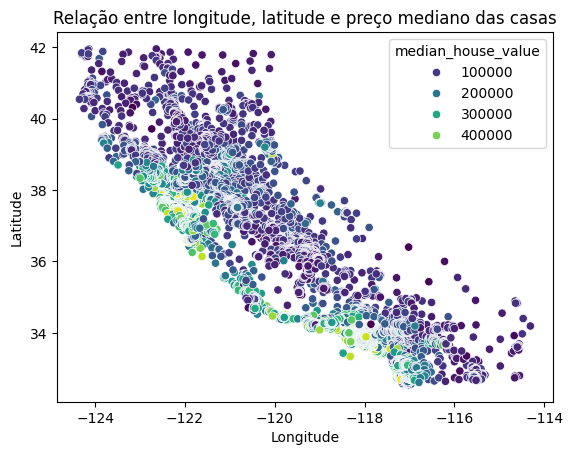

In [243]:
sns.scatterplot(data=df, x='longitude', y='latitude', hue='median_house_value', palette='viridis')
plt.title('Relação entre longitude, latitude e preço mediano das casas')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

Text(0.5, 1.0, 'Relação entre longitude, latitude e proximidade ao oceano')

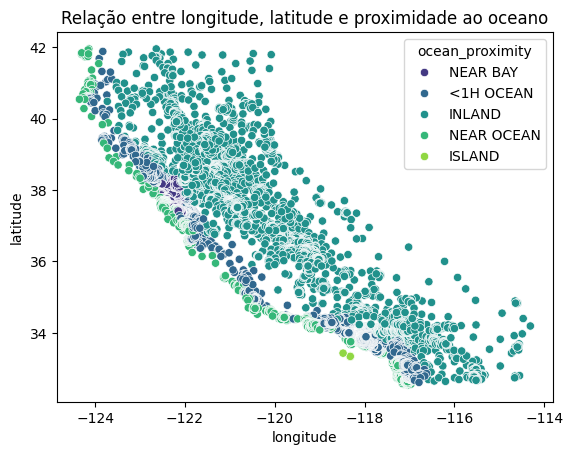

In [244]:
sns.scatterplot(data=df, x='longitude', y='latitude', hue='ocean_proximity', palette='viridis')
plt.title('Relação entre longitude, latitude e proximidade ao oceano')

In [245]:
##casas proximas ao mar sao mais caras, ou entao ilhas.

Text(0.5, 1.0, 'Matriz de correlação')

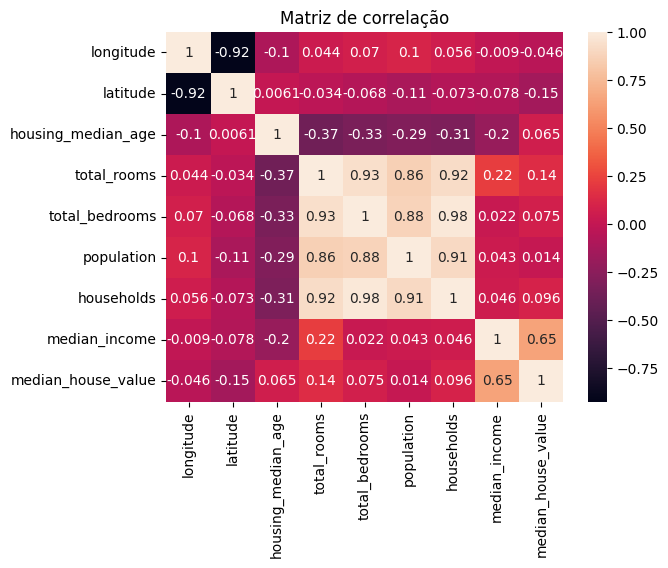

In [246]:
matrix_corr = df.corr(numeric_only=True)
sns.heatmap(matrix_corr, annot=True)
plt.title('Matriz de correlação')

In [247]:
##Bom, observe esse quadrado 4x4 totalmente bege no meio da figura, formados pelas variaveis total_rooms, population, households e total_bedrooms.
## Isso significa que elas estão altamente correlacionadas, o que é péssimo para um modelo linear e analises para verificar a importância de cada feature na previsão.
## Tambem podemos notar que existe uma correlação negativa entre longitude e latitude, mas isso nao quer dizer nada. Isso acontece somente porque as casas
## estão distribuídas na California, portanto, os dados se moldam no formato geografico da California, o que coincididentemente gera essa correalçao negativa.
## A outra correlação que observamos é entre a median_income e a median_house_value, nesse caso é algo bom pois a segunda é o que queremos prever.
## De resto, nada muito importante.

In [248]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19648.000000,19648.000000,19648.000000,19648.000000,19448.000000,19648.000000,19648.000000,19648.000000,19648.000000
mean,-119.562378,35.651872,28.373066,2620.337693,539.645825,1441.368485,501.192488,3.676411,192055.328583
std,2.005760,2.150066,12.504050,2182.371939,422.553057,1144.075196,383.391367,1.570602,97110.854998
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,297.000000,796.000000,282.000000,2.526300,116475.000000
50%,-118.500000,34.270000,28.000000,2111.000000,436.000000,1179.000000,411.000000,3.449050,173600.000000
75%,-117.990000,37.730000,37.000000,3121.000000,648.000000,1746.250000,606.000000,4.582500,247900.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,499100.000000


In [249]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median()) #aprox. cerca de 200 nulos, vamos preeencher assim..

Text(0.5, 1.0, 'Relação entre renda mediana dos moradores e preço mediano das casas')

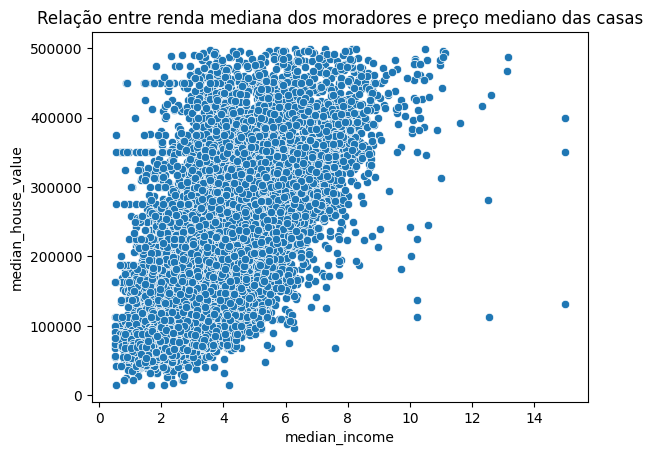

In [250]:
sns.scatterplot(data=df, x='median_income', y='median_house_value')
plt.title('Relação entre renda mediana dos moradores e preço mediano das casas')

Text(0.5, 1.0, 'Distribuição do preço mediano das casas')

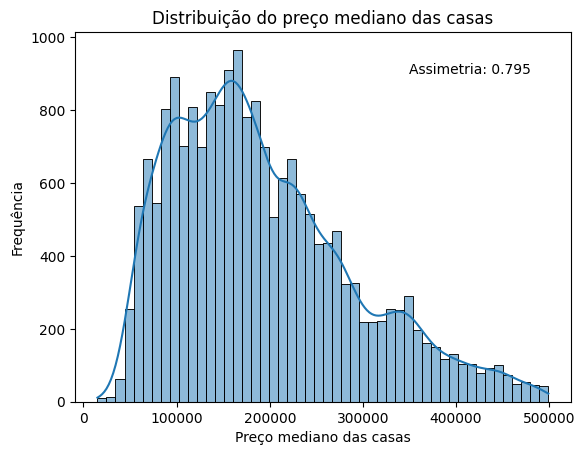

In [251]:
sns.histplot(data=df, x='median_house_value', kde=True)
plt.xlabel('Preço mediano das casas')
plt.ylabel('Frequência')
plt.text(350000, 900, f'Assimetria: {df.median_house_value.skew():.3f}')
plt.title('Distribuição do preço mediano das casas')

In [252]:
##assimetrias acima de 0.5 são consideradas altas

<Axes: ylabel='median_house_value'>

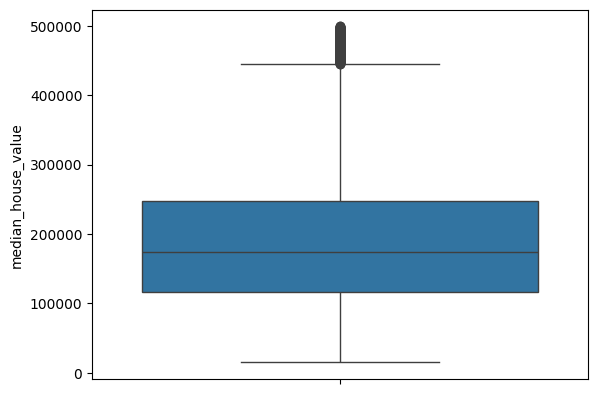

In [253]:
sns.boxplot(df['median_house_value'])

In [254]:
df_outliers = df[df['median_house_value'] > 440000]
df_outliers

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
140,-122.18,37.81,30.0,292.0,38.0,126.0,52.0,6.3624,483300.0,NEAR BAY
489,-122.25,37.86,48.0,2153.0,517.0,1656.0,459.0,3.0417,489600.0,NEAR BAY
490,-122.25,37.86,52.0,1389.0,191.0,514.0,202.0,7.0897,446200.0,NEAR BAY
491,-122.25,37.86,52.0,1709.0,318.0,719.0,295.0,5.0463,456300.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
18620,-122.03,37.00,30.0,2077.0,342.0,816.0,328.0,5.2078,440500.0,NEAR OCEAN
19542,-120.92,37.63,39.0,45.0,8.0,22.0,9.0,1.7679,450000.0,INLAND
20297,-119.22,34.15,32.0,3152.0,596.0,3490.0,526.0,2.7250,450000.0,NEAR OCEAN
20328,-119.09,34.24,17.0,10214.0,1589.0,3409.0,1327.0,5.3806,452100.0,<1H OCEAN


<Axes: xlabel='longitude', ylabel='latitude'>

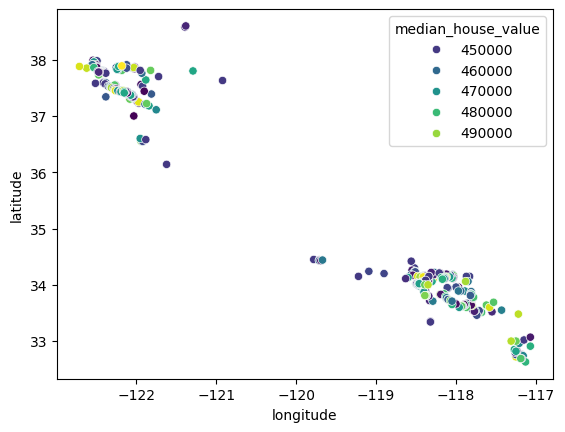

In [255]:
sns.scatterplot(data=df_outliers, x='longitude', y='latitude', hue='median_house_value', palette='viridis')

In [256]:
##Os outliers ficam proximos ao litoral sul ou norte da california (?)

Text(0, 0.5, 'Preço mediano das casas')

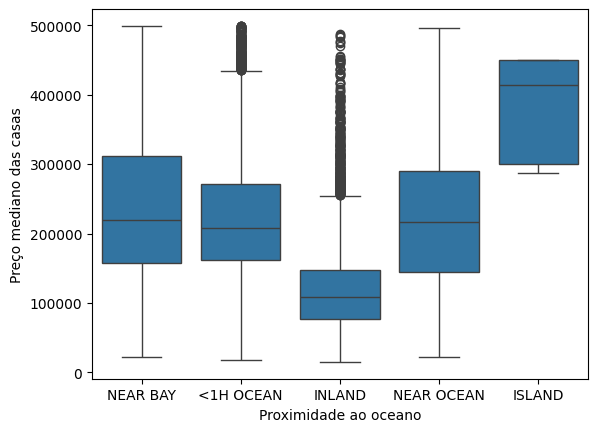

In [257]:
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value')
plt.xlabel('Proximidade ao oceano')
plt.ylabel('Preço mediano das casas')

In [258]:
## A gente consegue perceber que as medias e medianas se alteram entre as classes, porém, caso queiramos usar isso em um modelo, vai praticamente ser inútil, segue explicação:
## Todas classes, com exceção da ISLAND, possuem distribuições parecidas, amplitude tambem bem parecidas, o que siginifica que quando o modelo ver que a casa fica na NEAR BABY
## Ele nao vai prever um valor baseado na NEAR BABY, pois o preços da NEAR BABY tambem são muito comuns em outras classes, logo, a classe em si não faz diferença
## Para a previsão do modelo, pois todas as classes - excluindo ISLAND - tem seus preços de casas com uma variancia e amplitude altissima.
## Para o modelo conseguir usar isso como algo util, teriamos que criar uma nova coluna sendo a media/mediana de preço de cada classe.
## Contudo, isso poderia causar DATA LAKEAGE, então vamos optar por outra solução.
## Faremos varios cluester geograficos usando as variaveis long e lat, usando KMEANS

In [259]:
#As varaiveis total rooms e total berooms não possuem correlção por um simples motivo: Não é o numro de quartos e comodos por casa,
## Mas sim por blocos, logo, podemos criar uma coluna que use a interação das variaveis.
df['comodos_por_casas'] = df['total_rooms'] / df['households']
df['populacao_por_casas'] = df['population'] / df['households']

In [260]:
posicao_geografica = df[['longitude', 'latitude']]
clusters = KMeans(n_clusters=10, random_state=42, n_init='auto')

In [261]:
df['clusters'] = clusters.fit_predict(posicao_geografica)
df = pd.get_dummies(df, columns=['clusters'], drop_first=False)
df = df.drop(columns=['ocean_proximity'], axis=1) ## podemos remover para evitar redundância

In [262]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [263]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.1, random_state=42)
y_treino_log = np.log1p(y_treino) ##Transformação na variavel preditora para comprimir os outliers, diminuindo a assimetria

In [264]:
modelo = xgb.XGBRegressor(subsample=0.8, reg_lambda=2,reg_alpha=0.1,n_estimators=2000,
                          min_child_weight=15,max_depth=8,
                          learning_rate=0.01,
                          gamma=0.1,colsample_bytree=0.7,
                          random_state=42,
                          objective='reg:squarederror')
##A escolha dos hiperparametros foi feita atraves de um GridSearch que infelizmente não está mais presente nesse notebook devido minha falta de organização
## Optei pela função de perda squarederror para generalizar melhor, ir alem de prever somente valores medios e medianos.
## Isso vai custar um pouco do desemenho na previsão de casas com valores medios, mas não vai deixar o modelo completamente inútil para casas mais caras
## Posso usar squarederror mesmo com muitos outliers pois foi aplicado log na variavel dependente.

modelo.fit(X_treino, y_treino_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=15, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=None, num_parallel_tree=None, ...)

In [265]:
y_pred_treino = np.expm1(modelo.predict(X_treino))
y_pred_teste = np.expm1(modelo.predict(X_teste))

MAE_treino = mean_absolute_error(y_treino, y_pred_treino)
MAE_teste = mean_absolute_error(y_teste, y_pred_teste)
RMSE_teste = np.sqrt(mean_squared_error(y_teste, y_pred_teste))

r2_treino = r2_score(y_treino, y_pred_treino)
r2_teste = r2_score(y_teste, y_pred_teste)

print(f'MAE de treino: {MAE_treino}')
print(f'MAE de teste: {MAE_teste}')
print(f'RMSE de teste {RMSE_teste}')
print(f'R² de teste: {r2_teste * 100:.2f}%')

MAE de treino: 21343.229406531875
MAE de teste: 27733.815931138677
RMSE de teste 42745.647890871885
R² de teste: 80.53%


Text(0.5, 1.0, 'Gráfico de Resíduos')

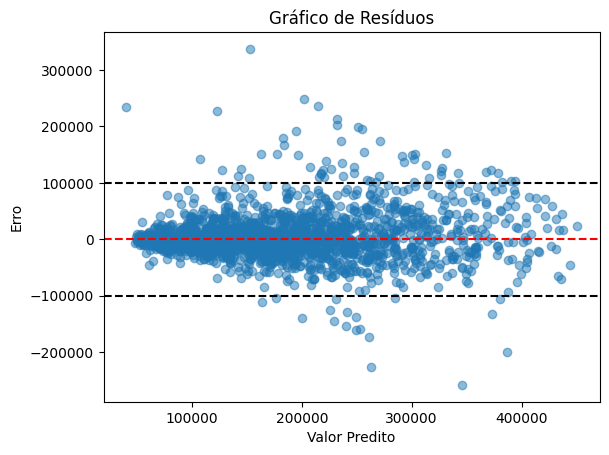

In [266]:
residuos = y_teste - y_pred_teste

plt.scatter(y_pred_teste, residuos, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.axhline(y=100000, color='black', linestyle='--')
plt.axhline(y=-100000, color='black', linestyle='--')
plt.xlabel('Valor Predito')
plt.ylabel('Erro')
plt.title('Gráfico de Resíduos')

In [267]:
## Erros negativos significam que o modelo superestimou o valor da casa, o que nao aconteceu mto de forma absurda, está ali na faixa de -100k
## Já erros positivos, siginifica que ele subestimou os preços das casas, o que aconteceu bastante, muitos erros acima de 100k.
## Ou seja: o modelo está muito humilde quanto a casas caras, prevendo valores menores.

In [268]:
dp_residuos = np.std(residuos)

print(f'MAE: {MAE_teste}')
print(f'Desvio Padrão dos Erros: {dp_residuos}')
print(f'RMSE: {RMSE_teste}')

MAE: 27733.815931138677
Desvio Padrão dos Erros: 42556.34621414177
RMSE: 42745.647890871885


In [269]:
mape = np.mean(np.abs((y_teste - y_pred_teste) / y_teste)) * 100
print(f'MAPE: {mape:.2f}%')

MAPE: 15.64%


Text(0, 0.5, 'Erro em porcentagem')

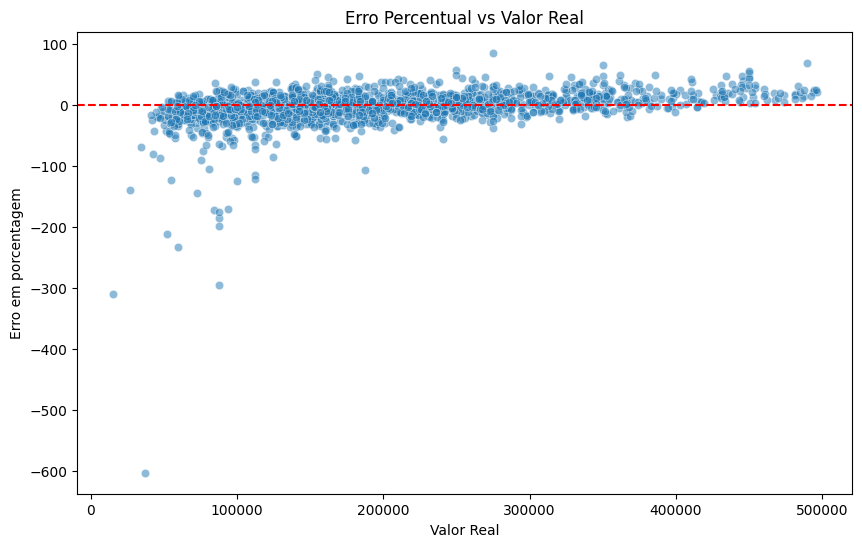

In [270]:
erro_percentual = ((y_teste - y_pred_teste) / y_teste) * 100

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_teste, y=erro_percentual, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Erro Percentual vs Valor Real')
plt.xlabel('Valor Real')
plt.ylabel('Erro em porcentagem')

In [271]:
##Modelo está bacana prevendo valores medios e medianos, errando aprox 15% para mais ou para menos.
## Superestimando casas com preço mto baixo e quando começa a chegar em casas mais caras ele subestima um pouco.